In [1]:
from fastai.vision.all import *
from pathlib import Path

import ipywidgets as widgets
from IPython.display import display, clear_output

In [2]:
from fastai.vision.all import *
from pathlib import Path

root = Path(".")

my_cat_dir = root / "my_cat_images"
not_my_cat_dir = root / "not_my_cat_images"

my_cat_files = get_image_files(my_cat_dir)
not_my_cat_files = get_image_files(not_my_cat_dir)

train_files = my_cat_files + not_my_cat_files

print("My cat images:", len(my_cat_files))
print("Not my cat images:", len(not_my_cat_files))
print("Total:", len(train_files))

My cat images: 48
Not my cat images: 50
Total: 98


In [3]:
def get_label(image_path):
    if my_cat_dir in image_path.parents:
        return "my_cat"

    return "not_my_cat"

In [4]:
cat_data = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=lambda source: train_files,
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    get_y=get_label,
    item_tfms=RandomResizedCrop(224, min_scale=0.5),
    batch_tfms=aug_transforms()
)

dls = cat_data.dataloaders(root, bs=8)

In [5]:
print(dls.vocab)

['my_cat', 'not_my_cat']


In [6]:
images, labels = dls.one_batch()

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Image dtype:", images.dtype)
print("Image device:", images.device)
print("Minimum image value:", images.min().item())
print("Maximum image value:", images.max().item())
print("Labels in this batch:", labels)
print("Contains NaN:", images.isnan().any().item())

Image batch shape: torch.Size([8, 3, 224, 224])
Label batch shape: torch.Size([8])
Image dtype: torch.float32
Image device: cpu
Minimum image value: 2.2665687104961307e-09
Maximum image value: 1.0
Labels in this batch: TensorCategory([0, 1, 1, 1, 1, 0, 0, 0])
Contains NaN: False


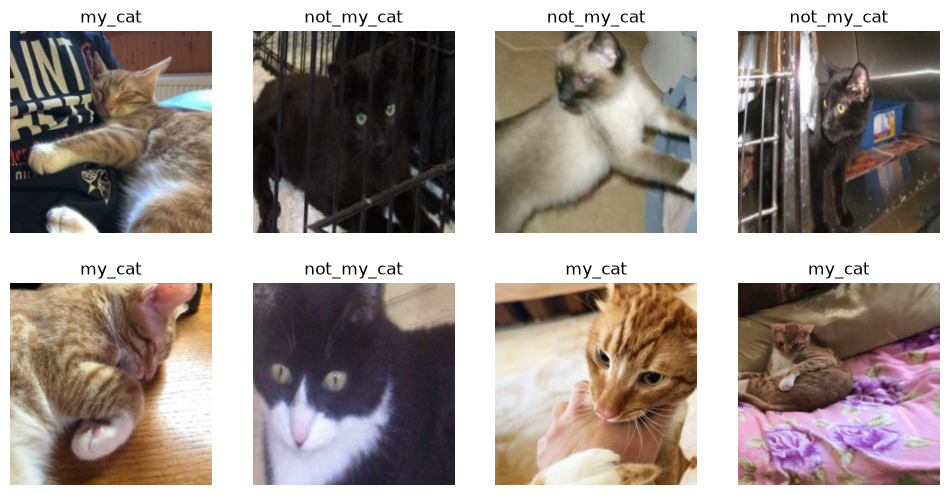

In [7]:
dls.show_batch(max_n=8, nrows=2)

In [8]:
learn = vision_learner(
    dls,
    resnet18,
    metrics=[accuracy, error_rate]
)

In [9]:
initial_results = learn.validate()

print("Initial validation loss:", initial_results[0])
print("Initial accuracy:", initial_results[1])
print("Initial error rate:", initial_results[2])

Initial validation loss: 2.4362354278564453
Initial accuracy: 0.5789473652839661
Initial error rate: 0.42105263471603394


epoch,train_loss,valid_loss,accuracy,error_rate,time
0,0.852955,0.911627,0.736842,0.263158,00:01


Better model found at epoch 0 with valid_loss value: 0.9116269946098328.


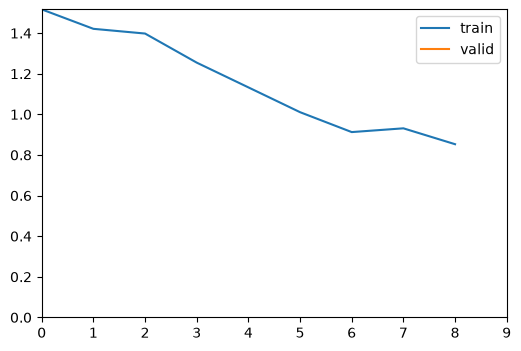

epoch,train_loss,valid_loss,accuracy,error_rate,time
0,0.254316,0.504519,0.842105,0.157895,00:01
1,0.223993,0.455851,0.894737,0.105263,00:01
2,0.156525,0.445283,0.842105,0.157895,00:01
3,0.130749,0.497311,0.842105,0.157895,00:02
4,0.160865,0.485149,0.842105,0.157895,00:02


Better model found at epoch 0 with valid_loss value: 0.5045190453529358.


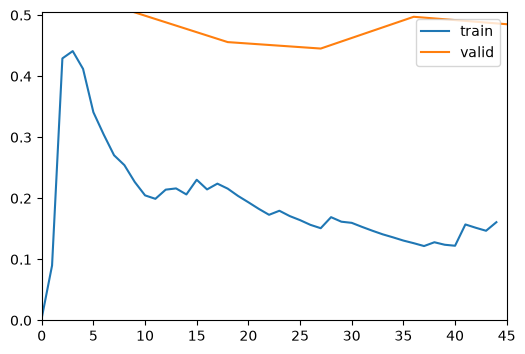

Better model found at epoch 1 with valid_loss value: 0.4558509886264801.
Better model found at epoch 2 with valid_loss value: 0.44528278708457947.


In [10]:
callbacks = [
    ShowGraphCallback(),
    SaveModelCallback(
        monitor="valid_loss",
        fname="my_cat_model"
    ),
    CSVLogger(fname="training_history.csv")
]

learn.fine_tune(
    5,
    cbs=callbacks
)

In [11]:
learn.load("my_cat_model", with_opt=False)

In [13]:
THRESHOLD = 0.90

# Upload control
uploader = widgets.FileUpload(
    accept="image/*",
    multiple=False,
    description="Upload image"
)

# Classification button
classify_button = widgets.Button(
    description="Is this my cat?",
    button_style="primary"
)

# Area for the image and result
output = widgets.Output()


def classify_uploaded_image(_):
    with output:
        clear_output(wait=True)

        if not uploader.value:
            print("Please upload an image first.")
            return

        try:
            # Get the first uploaded file
            uploaded_file = uploader.value[0]
            image_content = uploaded_file["content"]

            # Convert memoryview to bytes when necessary
            if hasattr(image_content, "tobytes"):
                image_content = image_content.tobytes()

            # Convert uploaded data into a fastai image
            img = PILImage.create(image_content)

            # Show a preview
            display(img.to_thumb(400, 400))

            # Get probabilities from the model
            _, _, probabilities = learn.predict(img)

            # Find the probability specifically for "my_cat"
            vocab = list(learn.dls.vocab)
            my_cat_index = vocab.index("my_cat")
            my_cat_probability = float(probabilities[my_cat_index])

            # Apply your application threshold
            if my_cat_probability >= THRESHOLD:
                print("Result: This is probably your cat")
            else:
                print("Result: This is probably not your cat")

            print(f"My cat probability: {my_cat_probability:.2%}")
            print(f"Acceptance threshold: {THRESHOLD:.0%}")

            # Optional: show probabilities for every class
            print("\nClass probabilities:")

            for class_name, probability in zip(vocab, probabilities):
                print(f"{class_name}: {float(probability):.2%}")

        except Exception as error:
            print(f"Could not process the image: {error}")


# Connect the button to the function
classify_button.on_click(classify_uploaded_image)

# Display the interface
display(
    widgets.VBox([
        widgets.HTML("<h3>Upload an image to check your cat</h3>"),
        uploader,
        classify_button,
        output
    ])
)

In [15]:
learn.export("my_cat_classifier.pkl")